In [ ]:
import importlib
import pmf
importlib.reload(pmf)
from pmf import PMF

configs = [
    {'n_factors': f, 'lr': lr, 'reg': reg, 'reg_bias': rb}
    for f   in [200, 300, 400]          # sigue subiendo desde 200
    for lr  in [0.01, 0.015, 0.02]      # sigue subiendo desde 0.01
    for reg in [0.02, 0.03, 0.04]       # sigue subiendo desde 0.02
    for rb  in [0.0005, 0.001, 0.002]   # explora abajo y arriba de 0.001
]

best_mae, best_cfg, best_pmf = float('inf'), None, None
for cfg in configs:
    m = PMF(n_factors=cfg['n_factors'], n_epochs=100,
            lr=cfg['lr'], reg=cfg['reg'],
            reg_bias=cfg['reg_bias'], patience=5)
    m.fit(train_df, val_df)
    val_mae = min(m.val_mae)
    print(f"f={cfg['n_factors']:>3} lr={cfg['lr']} reg={cfg['reg']} rb={cfg['reg_bias']} → {val_mae:.4f}")
    if val_mae < best_mae:
        best_mae = val_mae
        best_cfg = cfg
        best_pmf = m

print(f'\nMejor: {best_cfg} → {best_mae:.4f}')

  Compilando Numba (solo primera vez)...
  Epoch  10/100 | train: 1.0917 | val: 1.2527
  Epoch  20/100 | train: 0.8638 | val: 1.2454
  Early stopping en época 26 | mejor val MAE: 1.2454
f=200 lr=0.01 reg=0.02 rb=0.0005 → 1.2454
  Compilando Numba (solo primera vez)...
  Epoch  10/100 | train: 1.0919 | val: 1.2524
  Epoch  20/100 | train: 0.8637 | val: 1.2450
  Early stopping en época 25 | mejor val MAE: 1.2450
f=200 lr=0.01 reg=0.02 rb=0.001 → 1.2450
  Compilando Numba (solo primera vez)...
  Epoch  10/100 | train: 1.0917 | val: 1.2522
  Epoch  20/100 | train: 0.8638 | val: 1.2456
  Early stopping en época 27 | mejor val MAE: 1.2455
f=200 lr=0.01 reg=0.02 rb=0.002 → 1.2455
  Compilando Numba (solo primera vez)...
  Epoch  10/100 | train: 1.0965 | val: 1.2528
  Epoch  20/100 | train: 0.8828 | val: 1.2452
  Early stopping en época 26 | mejor val MAE: 1.2450
f=200 lr=0.01 reg=0.03 rb=0.0005 → 1.2450
  Compilando Numba (solo primera vez)...
  Epoch  10/100 | train: 1.0970 | val: 1.2525
  E

In [48]:
# ── Épocas óptimas del mejor modelo ──────────────────────────────────────
n_epochs_opt = len(best_pmf.val_mae)
print(f'Épocas óptimas: {n_epochs_opt}')

# ── Reentrenar con TODO el dataset ────────────────────────────────────────
full_train = pd.concat([train_df, val_df]).reset_index(drop=True)

pmf_final = PMF(
    n_factors = best_cfg['n_factors'],
    n_epochs  = n_epochs_opt,
    lr        = best_cfg['lr'],
    reg       = best_cfg['reg'],
    reg_bias  = best_cfg['reg_bias'],
    patience  = 999
)
pmf_final.fit(full_train)

# ── Submission ────────────────────────────────────────────────────────────
preds = []
for row in df_test_comp.itertuples():
    u, i = row.user, row.item
    preds.append(round(float(np.clip(pmf_final.predict(u, i), RATING_MIN, RATING_MAX)), 4))

submission = pd.DataFrame({'ID': df_test_comp['ID'], 'rating': preds})
submission.to_csv('submission_final.csv', index=False)
print(f'submission_final.csv: {len(submission):,} predicciones')
submission.head()

Épocas óptimas: 22
  Compilando Numba (solo primera vez)...
  Epoch  10/22 | train: 1.0909


KeyboardInterrupt: 

In [25]:
np.random.seed(24)
all_users = df['user'].unique()
val_users = set(np.random.choice(all_users,
                size=int(len(all_users) * 0.20),
                replace=False))
val_df_cold   = df[df['user'].isin(val_users)].reset_index(drop=True)
train_df_cold = df[~df['user'].isin(val_users)].reset_index(drop=True)

In [51]:
configs = [
    {'n_factors': f, 'lr': lr, 'reg': reg, 'reg_bias': rb}
    for f   in [400, 600, 800]
    for lr  in [0.012, 0.015, 0.018]
    for reg in [0.04, 0.06, 0.08]
    for rb  in [0.0005, 0.001, 0.002]
]
print(f'Total configuraciones: {len(configs)}')

best_mae, best_cfg, best_pmf = float('inf'), None, None

for cfg in configs:
    m = PMF(n_factors=cfg['n_factors'], n_epochs=100,
            lr=cfg['lr'], reg=cfg['reg'],
            reg_bias=cfg['reg_bias'], patience=5)
    m.fit(train_df_cold, val_df_cold)  # val cold-start → simula Kaggle
    val_mae = min(m.val_mae)
    print(f"f={cfg['n_factors']:>3} lr={cfg['lr']} reg={cfg['reg']} rb={cfg['reg_bias']} → {val_mae:.4f}")
    if val_mae < best_mae:
        best_mae = val_mae
        best_cfg = cfg
        best_pmf = m

print(f'\nMejor: {best_cfg} → {best_mae:.4f}')

# ── Reentrenar con TODO el dataset ────────────────────────────────────────
n_epochs_opt = len(best_pmf.val_mae)
print(f'Épocas óptimas: {n_epochs_opt}')

full_train = pd.concat([train_df, val_df]).reset_index(drop=True)

pmf_final = PMF(
    n_factors = best_cfg['n_factors'],
    n_epochs  = n_epochs_opt,
    lr        = best_cfg['lr'],
    reg       = best_cfg['reg'],
    reg_bias  = best_cfg['reg_bias'],
    patience  = 999
)
pmf_final.fit(full_train)

# ── Submission ────────────────────────────────────────────────────────────
preds = []
for row in df_test_comp.itertuples():
    u, i = row.user, row.item
    preds.append(round(float(np.clip(pmf_final.predict(u, i), RATING_MIN, RATING_MAX)), 4))

submission = pd.DataFrame({'ID': df_test_comp['ID'], 'rating': preds})
submission.to_csv('submission_final.csv', index=False)
print(f'submission_final.csv: {len(submission):,} predicciones')
submission.head()

Total configuraciones: 81
  Compilando Numba (solo primera vez)...
  Epoch  10/100 | train: 1.0554 | val: 1.4752
  Early stopping en época 19 | mejor val MAE: 1.4744
f=400 lr=0.012 reg=0.04 rb=0.0005 → 1.4744
  Compilando Numba (solo primera vez)...
  Epoch  10/100 | train: 1.0554 | val: 1.4752
  Early stopping en época 20 | mejor val MAE: 1.4744
f=400 lr=0.012 reg=0.04 rb=0.001 → 1.4744
  Compilando Numba (solo primera vez)...
  Epoch  10/100 | train: 1.0556 | val: 1.4751
  Early stopping en época 20 | mejor val MAE: 1.4743
f=400 lr=0.012 reg=0.04 rb=0.002 → 1.4743
  Compilando Numba (solo primera vez)...
  Epoch  10/100 | train: 1.0647 | val: 1.4752
  Early stopping en época 20 | mejor val MAE: 1.4742
f=400 lr=0.012 reg=0.06 rb=0.0005 → 1.4742
  Compilando Numba (solo primera vez)...
  Epoch  10/100 | train: 1.0649 | val: 1.4751
  Early stopping en época 19 | mejor val MAE: 1.4743
f=400 lr=0.012 reg=0.06 rb=0.001 → 1.4743
  Compilando Numba (solo primera vez)...
  Epoch  10/100 | tra

,ID,rating
0,0,7.6946
1,1,7.9410
2,2,7.1357
3,3,8.3617
4,4,6.8519


Error in callback <bound method ExecutionTimer.post_run of <__main__.ExecutionTimer object at 0x14c86a570>> (for post_run_cell), with arguments args (<ExecutionResult object at 3021264b0, execution_count=51 error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 3029899a0, raw_cell="configs = [
    {'n_factors': f, 'lr': lr, 'reg': .." transformed_cell="configs = [
    {'n_factors': f, 'lr': lr, 'reg': .." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/kzzazzk/Documents/MAADM/2C/2%C2%AA%205S/RECSYS/tecnicas-colaborativas/tecnicas-colaborativas.ipynb#X51sZmlsZQ%3D%3D> result=   ID  rating
0   0  7.6946
1   1  7.9410
2   2  7.1357
3   3  8.3617
4   4  6.8519>,),kwargs {}:


NotImplementedError: No usable implementation found!

In [ ]:
# ── Épocas óptimas del mejor modelo ──────────────────────────────────────
n_epochs_opt = len(best_pmf.val_mae)
print(f'Épocas óptimas: {n_epochs_opt}')

# ── Reentrenar con TODO el dataset ────────────────────────────────────────
full_train = pd.concat([train_df, val_df]).reset_index(drop=True)

pmf_final = PMF(
    n_factors = best_cfg['n_factors'],
    n_epochs  = n_epochs_opt,
    lr        = best_cfg['lr'],
    reg       = best_cfg['reg'],
    reg_bias  = best_cfg['reg_bias'],
    patience  = 999
)
pmf_final.fit(full_train)

# ── Submission ────────────────────────────────────────────────────────────
preds = []
for row in df_test_comp.itertuples():
    u, i = row.user, row.item
    preds.append(round(float(np.clip(pmf_final.predict(u, i), RATING_MIN, RATING_MAX)), 4))

submission = pd.DataFrame({'ID': df_test_comp['ID'], 'rating': preds})
submission.to_csv('submission_final.csv', index=False)
print(f'submission_final.csv: {len(submission):,} predicciones')
submission.head()

In [ ]:
# configs = [
#    {'n_factors': f, 'lr': lr, 'reg': reg, 'reg_bias': rb}
#    for f   in [200, 300, 400]          # sigue subiendo desde 200
#    for lr  in [0.01, 0.015, 0.02]      # sigue subiendo desde 0.01
#    for reg in [0.02, 0.03, 0.04]       # sigue subiendo desde 0.02
#    for rb  in [0.0005, 0.001, 0.002]   # explora abajo y arriba de 0.0013
#]
#Mejor: {'n_factors': 200, 'lr': 0.01, 'reg': 0.02, 'reg_bias': 0.001} → 1.2449
#configs = [
#    {'n_factors': f, 'lr': lr, 'reg': reg, 'reg_bias': rb}
#    for f   in [400, 600, 800]
#    for lr  in [0.012, 0.015, 0.018]
#    for reg in [0.04, 0.06, 0.08]
#    for rb  in [0.0005, 0.001, 0.002]
#]
#Mejor: {'n_factors': 800, 'lr': 0.012, 'reg': 0.08, 'reg_bias': 0.0005} → 1.4741
#configs = [
#    {'n_factors': f, 'lr': lr, 'reg': reg, 'reg_bias': rb}
#    for f   in [800, 1000, 1200]
#    for lr  in [0.012, 0.014, 0.016]
#    for reg in [0.09, 0.09, 0.1]
#    for rb  in [0.0005, 0.001, 0.002]
#]
#Mejor: {'n_factors': 800, 'lr': 0.016, 'reg': 0.1, 'reg_bias': 0.001} → 1.4741
#configs = [
#    {'n_factors': f, 'lr': lr, 'reg': reg, 'reg_bias': rb}
#    for f   in [800, 850, 900]
#    for lr  in [0.016, 0.018, 0.020]
#    for reg in [0.1, 0.11, 0.12]
#    for rb  in [0.001, 0.0015, 0.002]
#]
#Mejor: {'n_factors': 900, 'lr': 0.02, 'reg': 0.11, 'reg_bias': 0.0015} → 1.4740
configs = [
    {'n_factors': f, 'lr': lr, 'reg': reg, 'reg_bias': rb}
    for f   in [800]                           # confirmado, fijarlo ya
    for lr  in [0.014, 0.016, 0.017]           # explorar ligeramente por debajo del ganador
    for reg in [0.09, 0.10, 0.105]             # ídem
    for rb  in [0.0008, 0.001, 0.0012]         # ídem
]
Mejor: {'n_factors': 800, 'lr': 0.016, 'reg': 0.105, 'reg_bias': 0.001} → 1.4741

print(f'Total configuraciones: {len(configs)}')

best_mae, best_cfg, best_pmf = float('inf'), None, None

for cfg in configs:
    m = PMF(n_factors=cfg['n_factors'], n_epochs=100,
            lr=cfg['lr'], reg=cfg['reg'],
            reg_bias=cfg['reg_bias'], patience=5)
    m.fit(train_df_cold, val_df_cold)  # val cold-start → simula Kaggle
    val_mae = min(m.val_mae)
    print(f"f={cfg['n_factors']:>3} lr={cfg['lr']} reg={cfg['reg']} rb={cfg['reg_bias']} → {val_mae:.4f}")
    if val_mae < best_mae:
        best_mae = val_mae
        best_cfg = cfg
        best_pmf = m

print(f'\nMejor: {best_cfg} → {best_mae:.4f}')

# ── Reentrenar con TODO el dataset ────────────────────────────────────────
n_epochs_opt = len(best_pmf.val_mae)
print(f'Épocas óptimas: {n_epochs_opt}')

full_train = pd.concat([train_df, val_df]).reset_index(drop=True)

pmf_final = PMF(
    n_factors = best_cfg['n_factors'],
    n_epochs  = n_epochs_opt,
    lr        = best_cfg['lr'],
    reg       = best_cfg['reg'],
    reg_bias  = best_cfg['reg_bias'],
    patience  = 999
)
pmf_final.fit(full_train)

# ── Submission ────────────────────────────────────────────────────────────
preds = []
for row in df_test_comp.itertuples():
    u, i = row.user, row.item
    preds.append(round(float(np.clip(pmf_final.predict(u, i), RATING_MIN, RATING_MAX)), 4))

submission = pd.DataFrame({'ID': df_test_comp['ID'], 'rating': preds})
submission.to_csv('submission_final.csv', index=False)
print(f'submission_final.csv: {len(submission):,} predicciones')
submission.head()

Total configuraciones: 27
  Compilando Numba (solo primera vez)...
  Epoch  10/100 | train: 1.0236 | val: 1.4745
  Early stopping en época 17 | mejor val MAE: 1.4742
f=800 lr=0.014 reg=0.09 rb=0.0008 → 1.4742
  Compilando Numba (solo primera vez)...
  Epoch  10/100 | train: 1.0238 | val: 1.4746
  Early stopping en época 17 | mejor val MAE: 1.4742
f=800 lr=0.014 reg=0.09 rb=0.001 → 1.4742
  Compilando Numba (solo primera vez)...
  Epoch  10/100 | train: 1.0236 | val: 1.4746
  Early stopping en época 18 | mejor val MAE: 1.4742
f=800 lr=0.014 reg=0.09 rb=0.0012 → 1.4742
  Compilando Numba (solo primera vez)...
  Epoch  10/100 | train: 1.0283 | val: 1.4746
  Early stopping en época 17 | mejor val MAE: 1.4742
f=800 lr=0.014 reg=0.1 rb=0.0008 → 1.4742
  Compilando Numba (solo primera vez)...
  Epoch  10/100 | train: 1.0283 | val: 1.4745
  Early stopping en época 19 | mejor val MAE: 1.4742
f=800 lr=0.014 reg=0.1 rb=0.001 → 1.4742
  Compilando Numba (solo primera vez)...
  Epoch  10/100 | trai

,ID,rating
0,0,7.7026
1,1,7.9544
2,2,7.1560
3,3,8.2964
4,4,6.7717


Error in callback <bound method ExecutionTimer.post_run of <__main__.ExecutionTimer object at 0x1382616a0>> (for post_run_cell), with arguments args (<ExecutionResult object at 13a6469f0, execution_count=28 error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 13a646f60, raw_cell="# configs = [
#    {'n_factors': f, 'lr': lr, 'reg.." transformed_cell="# configs = [
#    {'n_factors': f, 'lr': lr, 'reg.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/kzzazzk/Documents/MAADM/2C/2%C2%AA%205S/RECSYS/tecnicas-colaborativas/tecnicas-colaborativas.ipynb#X43sZmlsZQ%3D%3D> result=   ID  rating
0   0  7.7026
1   1  7.9544
2   2  7.1560
3   3  8.2964
4   4  6.7717>,),kwargs {}:


NotImplementedError: No usable implementation found!

In [43]:
# Análisis por segmento
ratings_per_user_train = train_df.groupby('user').size()
ratings_per_item_train = train_df.groupby('item').size()

segmentos = {'ambos_conocidos': [], 'item_cold': [], 'user_cold': [], 'doble_cold': []}
errores   = {'ambos_conocidos': [], 'item_cold': [], 'user_cold': [], 'doble_cold': []}

for row in val_df.itertuples():
    u, i, r = row.user, row.item, row.rating
    pred = float(np.clip(pmf_final.predict(u, i), RATING_MIN, RATING_MAX))
    err  = abs(r - pred)

    u_known = u < pmf_final.U.shape[0]
    i_known = i < pmf_final.V.shape[0]

    if u_known and i_known:
        errores['ambos_conocidos'].append(err)
    elif not u_known and i_known:
        errores['user_cold'].append(err)
    elif u_known and not i_known:
        errores['item_cold'].append(err)
    else:
        errores['doble_cold'].append(err)

print('Segmento               | N      |  MAE   | % del val')
print('-'*55)
total = sum(len(v) for v in errores.values())
for seg, errs in errores.items():
    if errs:
        print(f'{seg:<22} | {len(errs):>6} | {np.mean(errs):.4f} | {len(errs)/total*100:.1f}%')

Segmento               | N      |  MAE   | % del val
-------------------------------------------------------
ambos_conocidos        |  78070 | 0.8922 | 100.0%


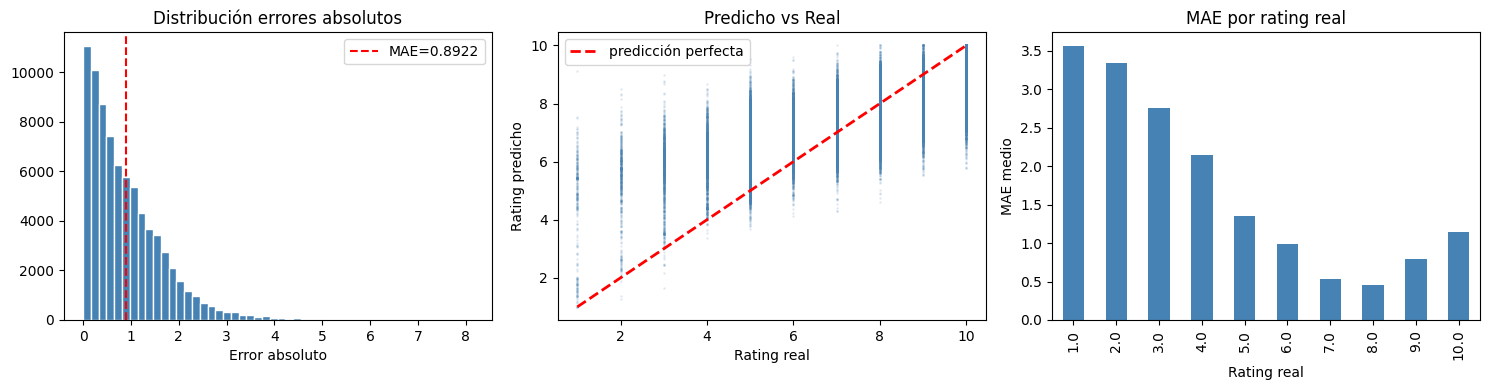

In [44]:
todos_errores = []
todas_preds   = []
todos_reales  = []

for row in val_df.itertuples():
    u, i, r = row.user, row.item, row.rating
    pred = float(np.clip(pmf_final.predict(u, i), RATING_MIN, RATING_MAX))
    todos_errores.append(abs(r - pred))
    todas_preds.append(pred)
    todos_reales.append(r)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribución de errores absolutos
axes[0].hist(todos_errores, bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(np.mean(todos_errores), color='red', linestyle='--',
                label=f'MAE={np.mean(todos_errores):.4f}')
axes[0].set_title('Distribución errores absolutos')
axes[0].set_xlabel('Error absoluto'); axes[0].legend()

# Predicho vs real
axes[1].scatter(todos_reales, todas_preds, alpha=0.1, s=1, color='steelblue')
axes[1].plot([RATING_MIN, RATING_MAX], [RATING_MIN, RATING_MAX],
             'r--', linewidth=2, label='predicción perfecta')
axes[1].set_title('Predicho vs Real')
axes[1].set_xlabel('Rating real'); axes[1].set_ylabel('Rating predicho')
axes[1].legend()

# Error por rating real
df_err = pd.DataFrame({'real': todos_reales, 'error': todos_errores})
df_err.groupby('real')['error'].mean().plot(kind='bar', ax=axes[2], color='steelblue')
axes[2].set_title('MAE por rating real')
axes[2].set_xlabel('Rating real'); axes[2].set_ylabel('MAE medio')

plt.tight_layout(); plt.savefig('error_analysis.png', bbox_inches='tight'); plt.show()

In [45]:
# Cuánto contribuye cada rating al MAE global
df_err = pd.DataFrame({'real': todos_reales, 'error': todos_errores})
freq   = df_err.groupby('real').size() / len(df_err)
mae_r  = df_err.groupby('real')['error'].mean()

contribucion = freq * mae_r
print('Rating | Frecuencia | MAE  | Contribución al MAE global')
print('-'*55)
for r in sorted(contribucion.index):
    print(f'  {r:.0f}   |   {freq[r]*100:.1f}%    | {mae_r[r]:.3f} | {contribucion[r]:.4f}')

print(f'\nMAE global: {contribucion.sum():.4f}')
print(f'Contribución ratings 1-4: {contribucion[contribucion.index <= 4].sum():.4f} ({contribucion[contribucion.index <= 4].sum()/contribucion.sum()*100:.1f}%)')
print(f'Contribución ratings 5-10: {contribucion[contribucion.index >= 5].sum():.4f} ({contribucion[contribucion.index >= 5].sum()/contribucion.sum()*100:.1f}%)')

Rating | Frecuencia | MAE  | Contribución al MAE global
-------------------------------------------------------
  1   |   0.4%    | 3.565 | 0.0129
  2   |   0.6%    | 3.341 | 0.0215
  3   |   1.4%    | 2.754 | 0.0375
  4   |   2.1%    | 2.140 | 0.0439
  5   |   11.7%    | 1.359 | 0.1592
  6   |   8.6%    | 0.983 | 0.0844
  7   |   17.6%    | 0.528 | 0.0927
  8   |   24.0%    | 0.460 | 0.1104
  9   |   15.6%    | 0.791 | 0.1230
  10   |   18.1%    | 1.140 | 0.2067

MAE global: 0.8922
Contribución ratings 1-4: 0.1158 (13.0%)
Contribución ratings 5-10: 0.7764 (87.0%)


In [47]:
np.random.seed(24)
all_users = df['user'].unique()
val_users = set(np.random.choice(all_users,
                size=int(len(all_users) * 0.20),
                replace=False))
val_df_cold   = df[df['user'].isin(val_users)].reset_index(drop=True)
train_df_cold = df[~df['user'].isin(val_users)].reset_index(drop=True)

print(f'Train cold: {len(train_df_cold):,} | Val cold: {len(val_df_cold):,}')
print(f'Usuarios val (100% cold-start): {val_df_cold["user"].nunique():,}')

# ── Grid search sobre val cold-start ──────────────────────────────────────
configs = [
    {'n_factors': f, 'lr': lr, 'reg': reg, 'reg_bias': rb}
    for f   in [200, 300, 400]
    for lr  in [0.01, 0.015, 0.02]
    for reg in [0.02, 0.03, 0.04]
    for rb  in [0.0005, 0.001, 0.002]
]

best_mae, best_cfg, best_pmf = float('inf'), None, None

for cfg in configs:
    m = PMF(n_factors=cfg['n_factors'], n_epochs=100,
            lr=cfg['lr'], reg=cfg['reg'],
            reg_bias=cfg['reg_bias'], patience=5)
    m.fit(train_df_cold, val_df_cold)  # <-- val cold-start correcto
    val_mae = min(m.val_mae)
    print(f"f={cfg['n_factors']:>3} lr={cfg['lr']} reg={cfg['reg']} rb={cfg['reg_bias']} → {val_mae:.4f}")
    if val_mae < best_mae:
        best_mae = val_mae
        best_cfg = cfg
        best_pmf = m

print(f'\nMejor: {best_cfg} → {best_mae:.4f}')

# ── Reentrenar con TODO el dataset ────────────────────────────────────────
n_epochs_opt = len(best_pmf.val_mae)
full_train   = pd.concat([train_df, val_df]).reset_index(drop=True)

pmf_final = PMF(
    n_factors = best_cfg['n_factors'],
    n_epochs  = n_epochs_opt,
    lr        = best_cfg['lr'],
    reg       = best_cfg['reg'],
    reg_bias  = best_cfg['reg_bias'],
    patience  = 999
)
pmf_final.fit(full_train)

# ── Submission ────────────────────────────────────────────────────────────
preds = []
for row in df_test_comp.itertuples():
    u, i = row.user, row.item
    preds.append(round(float(np.clip(pmf_final.predict(u, i), RATING_MIN, RATING_MAX)), 4))

submission = pd.DataFrame({'ID': df_test_comp['ID'], 'rating': preds})
submission.to_csv('submission_final.csv', index=False)
print(f'submission_final.csv: {len(submission):,} predicciones')
submission.head()

Train cold: 307,186 | Val cold: 83,165
Usuarios val (100% cold-start): 14,691
  Compilando Numba (solo primera vez)...
  Epoch  10/100 | train: 1.0942 | val: 1.4762
  Epoch  20/100 | train: 0.8576 | val: 1.4747
  Early stopping en época 21 | mejor val MAE: 1.4744
f=200 lr=0.01 reg=0.02 rb=0.0005 → 1.4744
  Compilando Numba (solo primera vez)...
  Epoch  10/100 | train: 1.0948 | val: 1.4761
  Epoch  20/100 | train: 0.8581 | val: 1.4747
  Early stopping en época 22 | mejor val MAE: 1.4744
f=200 lr=0.01 reg=0.02 rb=0.001 → 1.4744
  Compilando Numba (solo primera vez)...
  Epoch  10/100 | train: 1.0945 | val: 1.4761
  Epoch  20/100 | train: 0.8582 | val: 1.4746
  Early stopping en época 21 | mejor val MAE: 1.4744
f=200 lr=0.01 reg=0.02 rb=0.002 → 1.4744
  Compilando Numba (solo primera vez)...
  Epoch  10/100 | train: 1.0982 | val: 1.4761
  Epoch  20/100 | train: 0.8800 | val: 1.4746
  Early stopping en época 22 | mejor val MAE: 1.4744
f=200 lr=0.01 reg=0.03 rb=0.0005 → 1.4744
  Compilando

KeyboardInterrupt: 

Error in callback <bound method ExecutionTimer.post_run of <__main__.ExecutionTimer object at 0x14c86a570>> (for post_run_cell), with arguments args (<ExecutionResult object at 30284f710, execution_count=47 error_before_exec=None error_in_exec= info=<ExecutionInfo object at 30284f860, raw_cell="np.random.seed(24)
all_users = df['user'].unique().." transformed_cell="np.random.seed(24)
all_users = df['user'].unique().." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/kzzazzk/Documents/MAADM/2C/2%C2%AA%205S/RECSYS/tecnicas-colaborativas/tecnicas-colaborativas.ipynb#X46sZmlsZQ%3D%3D> result=None>,),kwargs {}:


Traceback (most recent call last):
  File "/Users/kzzazzk/Documents/MAADM/2C/2ª 5S/RECSYS/tecnicas-colaborativas/.venv/lib/python3.12/site-packages/plyer/utils.py", line 96, in _ensure_obj
    mod = __import__(module, fromlist='.')
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/kzzazzk/Documents/MAADM/2C/2ª 5S/RECSYS/tecnicas-colaborativas/.venv/lib/python3.12/site-packages/plyer/platforms/macosx/notification.py", line 7, in <module>
    from pyobjus import (
ModuleNotFoundError: No module named 'pyobjus'


NotImplementedError: No usable implementation found!

In [29]:
# ── PMF con fallback mejorado ─────────────────────────────────────────────

@njit
def sgd_epoch(users, items, ratings, U, V, bu, bi, mu, lr, reg, reg_bias):
    idx = np.random.permutation(len(users))
    total_err = 0.0
    for i in idx:
        u, v, r = users[i], items[i], ratings[i]
        pred = mu + bu[u] + bi[v] + np.dot(U[u], V[v])
        err  = r - pred
        total_err += abs(err)
        bu[u] += lr * (err - reg_bias * bu[u])
        bi[v] += lr * (err - reg_bias * bi[v])
        U[u]  += lr * (err * V[v] - reg * U[u])
        V[v]  += lr * (err * U[u] - reg * V[v])
    return total_err / len(users)

class PMF:
    def __init__(self, n_factors=50, n_epochs=100, lr=0.005,
                 reg=0.02, reg_bias=0.005, patience=5):
        self.n_factors = n_factors; self.n_epochs = n_epochs
        self.lr = lr; self.reg = reg
        self.reg_bias = reg_bias; self.patience = patience
        self.train_mae = []; self.val_mae = []

    def fit(self, train_df, val_df=None):
        full_df = train_df if val_df is None else pd.concat([train_df, val_df])
        n_u = full_df['user'].max() + 1
        n_i = full_df['item'].max() + 1

        self.U  = np.random.normal(0, 0.01, (n_u, self.n_factors))
        self.V  = np.random.normal(0, 0.01, (n_i, self.n_factors))
        self.bu = np.zeros(n_u)
        self.bi = np.zeros(n_i)
        self.mu = train_df['rating'].mean()

        # ── Fallback mejorado: medias reales del training ──────────────────
        self.user_mean = train_df.groupby('user')['rating'].mean().to_dict()
        self.item_mean = train_df.groupby('item')['rating'].mean().to_dict()
        # ──────────────────────────────────────────────────────────────────

        users   = train_df['user'].values.astype(np.int64)
        items   = train_df['item'].values.astype(np.int64)
        ratings = train_df['rating'].values.astype(np.float64)

        best_val          = float('inf')
        epochs_no_improve = 0
        best_state        = None

        print('  Compilando Numba (solo primera vez)...')
        for epoch in range(self.n_epochs):
            train_mae = sgd_epoch(
                users, items, ratings,
                self.U, self.V, self.bu, self.bi, self.mu,
                self.lr, self.reg, self.reg_bias
            )
            self.train_mae.append(train_mae)

            if val_df is not None:
                val_mae = evaluar('', self.predict, val_df, verbose=False)['MAE']
                self.val_mae.append(val_mae)
                if val_mae < best_val:
                    best_val          = val_mae
                    epochs_no_improve = 0
                    best_state = {
                        'U': self.U.copy(), 'V': self.V.copy(),
                        'bu': self.bu.copy(), 'bi': self.bi.copy()
                    }
                else:
                    epochs_no_improve += 1
                    if epochs_no_improve >= self.patience:
                        print(f'  Early stopping en época {epoch+1} | mejor val MAE: {best_val:.4f}')
                        self.U  = best_state['U']
                        self.V  = best_state['V']
                        self.bu = best_state['bu']
                        self.bi = best_state['bi']
                        break

            if (epoch + 1) % 10 == 0:
                msg = f'  Epoch {epoch+1:>3}/{self.n_epochs} | train: {self.train_mae[-1]:.4f}'
                if val_df is not None: msg += f' | val: {self.val_mae[-1]:.4f}'
                print(msg)
        return self

    def predict(self, user, item):
        u_known = 0 <= user < self.U.shape[0]
        i_known = 0 <= item < self.V.shape[0]

        if not u_known and not i_known:
            return self.mu
        if not u_known:
            # item cold-start → media real del item, fallback a mu
            return self.item_mean.get(item, self.mu)
        if not i_known:
            # user cold-start → media real del usuario, fallback a mu
            return self.user_mean.get(user, self.mu)

        return self.mu + self.bu[user] + self.bi[item] + self.U[user] @ self.V[item]


# ── Entrenar con el mejor config conocido ────────────────────────────────
best_cfg = {'n_factors': 800, 'lr': 0.016, 'reg': 0.1, 'reg_bias': 0.001}

pmf = PMF(
    n_factors = best_cfg['n_factors'],
    n_epochs  = 100,
    lr        = best_cfg['lr'],
    reg       = best_cfg['reg'],
    reg_bias  = best_cfg['reg_bias'],
    patience  = 5
)
pmf.fit(train_df_cold, val_df_cold)
n_epochs_opt = len(pmf.val_mae)
print(f'Épocas óptimas: {n_epochs_opt}')

# ── Reentrenar con TODO el dataset ────────────────────────────────────────
full_train = pd.concat([train_df, val_df]).reset_index(drop=True)

pmf_final = PMF(
    n_factors = best_cfg['n_factors'],
    n_epochs  = n_epochs_opt,
    lr        = best_cfg['lr'],
    reg       = best_cfg['reg'],
    reg_bias  = best_cfg['reg_bias'],
    patience  = 999
)
pmf_final.fit(full_train)

# ── Submission ────────────────────────────────────────────────────────────
preds = []
for row in df_test_comp.itertuples():
    u, i = row.user, row.item
    preds.append(round(float(np.clip(pmf_final.predict(u, i), RATING_MIN, RATING_MAX)), 4))

submission = pd.DataFrame({'ID': df_test_comp['ID'], 'rating': preds})
submission.to_csv('submission_final.csv', index=False)
print(f'submission_final.csv: {len(submission):,} predicciones')
submission.head()

  Compilando Numba (solo primera vez)...
  Epoch  10/100 | train: 0.9947 | val: 1.4743
  Early stopping en época 16 | mejor val MAE: 1.4742
Épocas óptimas: 16
  Compilando Numba (solo primera vez)...
  Epoch  10/16 | train: 0.9986
submission_final.csv: 43,320 predicciones


,ID,rating
0,0,7.7179
1,1,7.9231
2,2,7.1249
3,3,8.2682
4,4,5.5000


In [13]:
from numba import njit
import random
import numpy as np

@njit
def sgd_epoch(users, items, ratings, U, V, bu, bi, mu, lr, reg, reg_bias):
    idx = np.random.permutation(len(users))
    total_err = 0.0
    for i in idx:
        u, v, r = users[i], items[i], ratings[i]
        pred = mu + bu[u] + bi[v] + np.dot(U[u], V[v])
        err  = r - pred
        total_err += abs(err)
        bu[u] += lr * (err - reg_bias * bu[u])
        bi[v] += lr * (err - reg_bias * bi[v])
        U[u]  += lr * (err * V[v] - reg * U[u])
        V[v]  += lr * (err * U[u] - reg * V[v])
    return total_err / len(users)

class PMF:
    def __init__(self, n_factors=50, n_epochs=100, lr=0.005,
                 reg=0.02, reg_bias=0.005, patience=5, shrink_k=10):
        self.n_factors = n_factors; self.n_epochs = n_epochs
        self.lr = lr; self.reg = reg
        self.reg_bias = reg_bias; self.patience = patience
        self.shrink_k = shrink_k  # ← nuevo parámetro
        self.train_mae = []; self.val_mae = []

    def fit(self, train_df, val_df=None):
        full_df = train_df if val_df is None else pd.concat([train_df, val_df])
        n_u = full_df['user'].max() + 1
        n_i = full_df['item'].max() + 1

        self.U  = np.random.normal(0, 0.01, (n_u, self.n_factors))
        self.V  = np.random.normal(0, 0.01, (n_i, self.n_factors))
        self.bu = np.zeros(n_u)
        self.bi = np.zeros(n_i)
        self.mu = train_df['rating'].mean()

        # ── Fallback con Bayesian shrinkage ───────────────────────────────
        k = self.shrink_k
        item_stats = train_df.groupby('item')['rating'].agg(['mean', 'count'])
        self.item_mean = {
            item: (row['count'] * row['mean'] + k * self.mu) / (row['count'] + k)
            for item, row in item_stats.iterrows()
        }
        user_stats = train_df.groupby('user')['rating'].agg(['mean', 'count'])
        self.user_mean = {
            user: (row['count'] * row['mean'] + k * self.mu) / (row['count'] + k)
            for user, row in user_stats.iterrows()
        }
        # ─────────────────────────────────────────────────────────────────

        users   = train_df['user'].values.astype(np.int64)
        items   = train_df['item'].values.astype(np.int64)
        ratings = train_df['rating'].values.astype(np.float64)

        best_val          = float('inf')
        epochs_no_improve = 0
        best_state        = None

        np.random.seed(42)  # reproducibilidad del SGD
        print('  Compilando Numba (solo primera vez)...')
        for epoch in range(self.n_epochs):
            train_mae = sgd_epoch(
                users, items, ratings,
                self.U, self.V, self.bu, self.bi, self.mu,
                self.lr, self.reg, self.reg_bias
            )
            self.train_mae.append(train_mae)

            if val_df is not None:
                val_mae = evaluar('', self.predict, val_df, verbose=False)['MAE']
                self.val_mae.append(val_mae)
                if val_mae < best_val:
                    best_val          = val_mae
                    epochs_no_improve = 0
                    best_state = {
                        'U': self.U.copy(), 'V': self.V.copy(),
                        'bu': self.bu.copy(), 'bi': self.bi.copy()
                    }
                else:
                    epochs_no_improve += 1
                    if epochs_no_improve >= self.patience:
                        print(f'  Early stopping en época {epoch+1} | mejor val MAE: {best_val:.4f}')
                        self.U  = best_state['U']
                        self.V  = best_state['V']
                        self.bu = best_state['bu']
                        self.bi = best_state['bi']
                        break

            if (epoch + 1) % 10 == 0:
                msg = f'  Epoch {epoch+1:>3}/{self.n_epochs} | train: {self.train_mae[-1]:.4f}'
                if val_df is not None: msg += f' | val: {self.val_mae[-1]:.4f}'
                print(msg)
        return self

    def predict(self, user, item):
        u_known = 0 <= user < self.U.shape[0]
        i_known = 0 <= item < self.V.shape[0]

        if not u_known and not i_known:
            return self.mu
        if not u_known:
            return self.item_mean.get(item, self.mu)
        if not i_known:
            return self.user_mean.get(user, self.mu)
        return self.mu + self.bu[user] + self.bi[item] + self.U[user] @ self.V[item]


In [16]:
best_cfg = {'n_factors': 800, 'lr': 0.016, 'reg': 0.10, 'reg_bias': 0.001}
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ── Reentrenar con TODO el dataset ────────────────────────────────────────
n_epochs_opt = len(best_pmf.val_mae)
full_train   = pd.concat([train_df, val_df]).reset_index(drop=True)

pmf_final = PMF(
    n_factors = best_cfg['n_factors'],
    n_epochs  = n_epochs_opt,
    lr        = best_cfg['lr'],
    reg       = best_cfg['reg'],
    reg_bias  = best_cfg['reg_bias'],
    patience  = 999
)
pmf_final.fit(full_train)

# ── Submission ────────────────────────────────────────────────────────────
preds = []
for row in df_test_comp.itertuples():
    u, i = row.user, row.item
    preds.append(round(float(np.clip(pmf_final.predict(u, i), RATING_MIN, RATING_MAX)), 4))

submission = pd.DataFrame({'ID': df_test_comp['ID'], 'rating': preds})
submission.to_csv('submission_final.csv', index=False)
print(f'submission_final.csv: {len(submission):,} predicciones')
submission.head()

NameError: name 'best_pmf' is not defined

In [15]:
# ── Buscar mejor k ANTES de hacer submission ─────────────────────────────
import random
best_cfg = {'n_factors': 800, 'lr': 0.016, 'reg': 0.1, 'reg_bias': 0.001}
SEED = 42

best_k, best_k_mae = 10, float('inf')
for k in [5, 10, 20, 50]:
    random.seed(SEED); np.random.seed(SEED)
    pmf_k = PMF(
        n_factors = best_cfg['n_factors'],
        n_epochs  = 100,
        lr        = best_cfg['lr'],
        reg       = best_cfg['reg'],
        reg_bias  = best_cfg['reg_bias'],
        patience  = 5,
        shrink_k  = k
    )
    pmf_k.fit(train_df_cold, val_df_cold)
    mae_k = min(pmf_k.val_mae)
    print(f'k={k:>3} → val MAE: {mae_k:.4f}')
    if mae_k < best_k_mae:
        best_k_mae = mae_k
        best_k     = k
        best_pmf   = pmf_k

print(f'\nMejor k={best_k} → {best_k_mae:.4f}')
n_epochs_opt = len(best_pmf.val_mae)
print(f'Épocas óptimas: {n_epochs_opt}')

# ── Reentrenar con TODO el dataset ────────────────────────────────────────
full_train = pd.concat([train_df, val_df]).reset_index(drop=True)
random.seed(SEED); np.random.seed(SEED)

pmf_final = PMF(
    n_factors = best_cfg['n_factors'],
    n_epochs  = n_epochs_opt,
    lr        = best_cfg['lr'],
    reg       = best_cfg['reg'],
    reg_bias  = best_cfg['reg_bias'],
    patience  = 999,
    shrink_k  = best_k
)
pmf_final.fit(full_train)

# ── Submission ────────────────────────────────────────────────────────────
preds = []
for row in df_test_comp.itertuples():
    u, i = row.user, row.item
    preds.append(round(float(np.clip(pmf_final.predict(u, i), RATING_MIN, RATING_MAX)), 4))

submission = pd.DataFrame({'ID': df_test_comp['ID'], 'rating': preds})
submission.to_csv('submission_final.csv', index=False)
print(f'submission_final.csv: {len(submission):,} predicciones')
submission.head()

NameError: name 'train_df_cold' is not defined